<a href="https://colab.research.google.com/github/HippomasAKiB1/CNN_23-50531-1/blob/main/CNN_23_50531_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN for Multi-Label Remote Sensing Scene Classification
**Student ID**: 23-50531-1  
**Dataset**: MLRSNet (Multi-Label High Spatial Resolution Remote Sensing Dataset)  
**Task**: Multi-label image classification across 60 semantic labels

This notebook trains a custom CNN on MLRSNet satellite images and compares performance with and without batch normalization and dropout regularization.

> **Running on Google Colab**: **T4 GPU**

## 0. Colab Setup — Drive, Kaggle & Output Folder


In [1]:
# Step 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


In [2]:
# Step 2 — Create output folder on Drive

import os
OUTPUT_DIR = '/content/drive/MyDrive/CNN_23-50531-1'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output folder ready: {OUTPUT_DIR}')
print('Files will be saved to:')
for f in ['best_with_reg.pth', 'best_without_reg.pth',
          'label_distribution.png', 'training_curves.png',
          'per_class_metrics.png', 'confusion_matrix.png']:
    print(f'  {OUTPUT_DIR}/{f}')

Output folder ready: /content/drive/MyDrive/CNN_23-50531-1
Files will be saved to:
  /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth
  /content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth
  /content/drive/MyDrive/CNN_23-50531-1/label_distribution.png
  /content/drive/MyDrive/CNN_23-50531-1/training_curves.png
  /content/drive/MyDrive/CNN_23-50531-1/per_class_metrics.png
  /content/drive/MyDrive/CNN_23-50531-1/confusion_matrix.png


In [3]:
# Step 3 — Get dataset into /content/mlrs-net

import os

COLAB_DATASET = '/content/mlrs-net'

if os.path.exists(COLAB_DATASET) and os.path.exists(os.path.join(COLAB_DATASET, 'splits')):
    print('Dataset already in /content — skipping.')


else:
    print('Dataset not found — downloading from Kaggle for the first time...')
    !pip install kaggle -q
    from google.colab import files
    files.upload()  # upload kaggle.json
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d vigneshwar472/mlrs-net --unzip -p /content/
    print('Saving a copy to Drive so future sessions skip the download...')



Dataset not found — downloading from Kaggle for the first time...


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vigneshwar472/mlrs-net
License(s): CC-BY-SA-4.0
100% 2.47G/2.47G [00:18<00:00, 141MB/s]

Saving a copy to Drive so future sessions skip the download...


In [23]:
#move and check if dataset exists
!mkdir -p /content/mlrs-net
!mv /content/images /content/mlrs-net/
!mv /content/labels /content/mlrs-net/
!mv /content/splits /content/mlrs-net/
!ls /content/mlrs-net

mv: cannot stat '/content/images': No such file or directory
mv: cannot stat '/content/labels': No such file or directory
mv: cannot stat '/content/splits': No such file or directory
images	labels	splits


## 1. Import Libraries

In [5]:
import os
import ast
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import precision_recall_fscore_support

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## 2. Load and Explore Dataset

MLRSNet is a multi-label remote sensing dataset with 109,161 satellite images at 256x256 px across 46 scene categories and 60 semantic labels.

**Folder structure:**
```
mlrs-net/
  images/           <- 46 category subfolders
  labels/           <- 46 CSVs (one per category)
  splits/
    train/
      train_labels.csv
      images/  <- train_0.jpg, train_1.jpg, ...
    test/
      test_labels.csv
      images/
    validation/
      validation_labels.csv
      images/
```

In [6]:
# Paths
data_root  = '/content/mlrs-net'
splits_dir = os.path.join(data_root, 'splits')

TRAIN_CSV = os.path.join(splits_dir, 'train',      'train_labels.csv')
VAL_CSV   = os.path.join(splits_dir, 'validation',  'validation_labels.csv')
TEST_CSV  = os.path.join(splits_dir, 'test',        'test_labels.csv')

TRAIN_IMG = os.path.join(splits_dir, 'train',      'images')
VAL_IMG   = os.path.join(splits_dir, 'validation',  'images')
TEST_IMG  = os.path.join(splits_dir, 'test',        'images')

for p in [TRAIN_CSV, VAL_CSV, TEST_CSV, TRAIN_IMG, VAL_IMG, TEST_IMG]:
    print(f"{'OK' if os.path.exists(p) else 'MISSING'}  {p}")

OK  /content/mlrs-net/splits/train/train_labels.csv
OK  /content/mlrs-net/splits/validation/validation_labels.csv
OK  /content/mlrs-net/splits/test/test_labels.csv
OK  /content/mlrs-net/splits/train/images
OK  /content/mlrs-net/splits/validation/images
OK  /content/mlrs-net/splits/test/images


In [7]:
# Peek at CSV format
sample_df = pd.read_csv(TRAIN_CSV)
print('Columns:', sample_df.columns.tolist())
print(f'Rows   : {len(sample_df):,}')
sample_df.head(5)

Columns: ['image_id', 'labels']
Rows   : 65,489


,image_id,labels
0,train_0,"['bare soil', 'forest', 'trail', 'trees']"
1,train_1,"['buildings', 'cars', 'park', 'trail', 'trees'..."
2,train_2,"['desert', 'sand']"
3,train_3,"['bare soil', 'buildings', 'cars', 'pavement',..."
4,train_4,"['bare soil', 'transmission tower']"


In [8]:
LABEL_COL = 'labels'
ID_COL    = 'image_id'

all_dfs = {
    'train': pd.read_csv(TRAIN_CSV),
    'val'  : pd.read_csv(VAL_CSV),
    'test' : pd.read_csv(TEST_CSV),
}

def parse_labels(lbl_str):
    """Parse label string — handles Python list-style strings like ['bare soil', 'trees']."""
    s = str(lbl_str).strip()
    if s.startswith('['):
        return [l.strip() for l in ast.literal_eval(s)]
    return [l.strip() for l in s.split(',')]

# Build global label vocabulary from all three splits
unique_labels = set()
for split_df in all_dfs.values():
    for lbl_str in split_df[LABEL_COL].dropna():
        for lbl in parse_labels(lbl_str):
            unique_labels.add(lbl)

label_names = sorted(unique_labels)
label2idx   = {lbl: i for i, lbl in enumerate(label_names)}
NUM_CLASSES = len(label_names)
print(f'Total unique labels : {NUM_CLASSES}')
print(f'First 10            : {label_names[:10]}')

Total unique labels : 60
First 10            : ['airplane', 'airport', 'bare soil', 'baseball diamond', 'basketball court', 'beach', 'bridge', 'buildings', 'cars', 'chaparral']


In [9]:
def df_to_label_vectors(df, label2idx, num_classes, label_col, id_col):
    """
    Convert a split DataFrame into:
      image_ids  : list of image IDs (filenames without .jpg)
      label_vecs : dict { image_id -> np.float32 binary vector }
    """
    image_ids  = []
    label_vecs = {}
    for _, row in df.iterrows():
        img_id  = str(row[id_col])
        lbl_str = row[label_col]
        vec = np.zeros(num_classes, dtype=np.float32)
        if pd.notna(lbl_str):
            for lbl in parse_labels(lbl_str):
                if lbl in label2idx:
                    vec[label2idx[lbl]] = 1.0
        image_ids.append(img_id)
        label_vecs[img_id] = vec
    return image_ids, label_vecs

train_ids, train_vecs = df_to_label_vectors(all_dfs['train'], label2idx, NUM_CLASSES, LABEL_COL, ID_COL)
val_ids,   val_vecs   = df_to_label_vectors(all_dfs['val'],   label2idx, NUM_CLASSES, LABEL_COL, ID_COL)
test_ids,  test_vecs  = df_to_label_vectors(all_dfs['test'],  label2idx, NUM_CLASSES, LABEL_COL, ID_COL)

print(f'Split sizes — Train: {len(train_ids):,}  Val: {len(val_ids):,}  Test: {len(test_ids):,}')

Split sizes — Train: 65,489  Val: 21,830  Test: 21,842


Average labels per image (train): 5.02


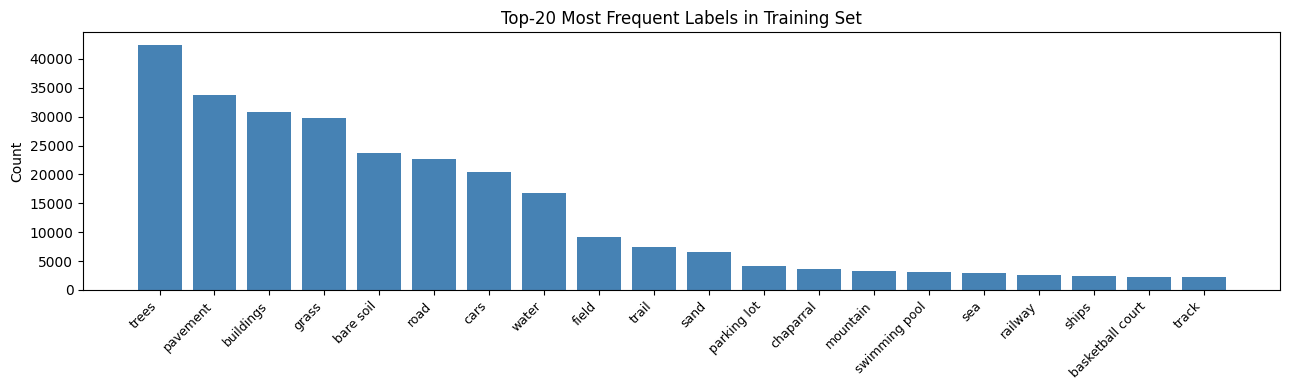

Saved: label_distribution.png


In [10]:
# Label frequency in training set
train_mat  = np.stack(list(train_vecs.values()))
label_freq = train_mat.sum(axis=0)
avg_labels = train_mat.sum(axis=1).mean()
print(f'Average labels per image (train): {avg_labels:.2f}')

top20_idx   = np.argsort(label_freq)[-20:][::-1]
top20_names = [label_names[i] for i in top20_idx]
top20_freq  = label_freq[top20_idx]

plt.figure(figsize=(13, 4))
plt.bar(top20_names, top20_freq, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Top-20 Most Frequent Labels in Training Set')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'label_distribution.png'), dpi=150)
plt.show()
print('Saved: label_distribution.png')

## 3. Data Preprocessing & Augmentation

All images are 256x256 px. Preprocessing strategy:
- **Training**: random horizontal flip, random rotation (+-10 deg), color jitter.
- **Validation / Test**: normalization only — ensures deterministic, fair evaluation.
- **Normalization**: ImageNet mean/std — standard practice for satellite imagery CNNs.

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MLRSNetDataset(Dataset):
    """
    PyTorch Dataset for one split of MLRSNet.

    Args:
        image_ids  : list of image IDs (e.g. 'train_0', 'test_42')
        label_vecs : dict { image_id -> np.float32 binary vector }
        img_dir    : folder containing this split's .jpg files
        transform  : torchvision transform pipeline
    """
    def __init__(self, image_ids, label_vecs, img_dir, transform=None):
        self.image_ids  = image_ids
        self.label_vecs = label_vecs
        self.img_dir    = img_dir
        self.transform  = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id   = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_id + '.jpg')
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.from_numpy(self.label_vecs[img_id])
        return image, label


# using colab t4 gpu so 64 is safe
BATCH_SIZE  = 64
NUM_WORKERS = 2   # Linux (Colab) supports multiple workers

train_dataset = MLRSNetDataset(train_ids, train_vecs, TRAIN_IMG, transform=train_transform)
val_dataset   = MLRSNetDataset(val_ids,   val_vecs,   VAL_IMG,   transform=eval_transform)
test_dataset  = MLRSNetDataset(test_ids,  test_vecs,  TEST_IMG,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Batches — Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

# Verify one batch loads correctly
imgs, lbls = next(iter(train_loader))
print(f'Batch shape — images: {imgs.shape}  labels: {lbls.shape}')

Batches — Train: 1024  Val: 342  Test: 342
Batch shape — images: torch.Size([64, 3, 256, 256])  labels: torch.Size([64, 60])


## 4. Define CNN Architecture

We build a `CustomCNN` with four convolutional blocks. Each block contains two Conv->(BN)->ReLU layers followed by 2x2 max pooling. The classifier head uses Global Average Pooling (GAP) instead of flattening — this dramatically reduces parameters.

| Block | Output Channels | Spatial Size |
|---|---|---|
| Input | 3 | 256x256 |
| Block 1 + Pool | 32 | 128x128 |
| Block 2 + Pool | 64 | 64x64 |
| Block 3 + Pool | 128 | 32x32 |
| Block 4 + Pool | 256 | 16x16 |
| Global Avg Pool | 256 | 1x1 |
| FC (512) -> FC (60) | — | — |

`use_bn` and `use_dropout` flags allow identical architectures with/without regularization for a fair A/B comparison. Output is raw logits.

In [12]:
class CustomCNN(nn.Module):
    """
    Custom CNN for multi-label remote sensing classification.

    Args:
        num_classes  : number of output labels (60 for MLRSNet)
        use_bn       : apply BatchNorm after each Conv and FC layer
        use_dropout  : apply Dropout before the final classifier
        dropout_rate : dropout probability
    """
    def __init__(self, num_classes, use_bn=True, use_dropout=True, dropout_rate=0.5):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=not use_bn),
                nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=not use_bn),
                nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(),
                nn.ReLU(inplace=True),
            )

        self.block1 = conv_block(3,    32)
        self.block2 = conv_block(32,   64)
        self.block3 = conv_block(64,  128)
        self.block4 = conv_block(128, 256)
        self.pool   = nn.MaxPool2d(2, 2)
        self.gap    = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate) if use_dropout else nn.Identity(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.pool(self.block1(x))
        x = self.pool(self.block2(x))
        x = self.pool(self.block3(x))
        x = self.pool(self.block4(x))
        x = self.gap(x)
        return self.classifier(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_reg   = CustomCNN(NUM_CLASSES, use_bn=True,  use_dropout=True ).to(device)
model_noreg = CustomCNN(NUM_CLASSES, use_bn=False, use_dropout=False).to(device)

print(f'Parameters (with reg)    : {count_params(model_reg):,}')
print(f'Parameters (without reg) : {count_params(model_noreg):,}')
print(f'\nArchitecture (with reg):')
print(model_reg)

Parameters (with reg)    : 1,336,604
Parameters (without reg) : 1,334,620

Architecture (with reg):
CustomCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (block3): Sequen

## 5. Training Loop with Validation

**Hyperparameter choices and rationale:**

| Hyperparameter | Value | Reason |
|---|---|---|
| Loss | BCEWithLogitsLoss | Numerically stable multi-label BCE |
| Optimizer | Adam, lr=1e-3 | Adaptive LR, faster convergence than SGD |
| Weight decay | 1e-4 | L2 regularization, prevents large weights |
| LR scheduler | ReduceLROnPlateau (x0.5, patience=2) | Halves LR when val loss stagnates |
| Early stopping | patience=4 | Avoids overfitting |
| Epochs | 15 max | Sufficient with scheduling |
| Batch size | 64 | Optimal for T4 GPU |

In [13]:
def train_model(model, train_loader, val_loader, epochs, lr=1e-3, label='model'):
    """
    Train model and return loss/accuracy history.
    Saves best checkpoint to best_{label}.pth.
    """
    criterion  = nn.BCEWithLogitsLoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5
    )
    save_path  = os.path.join(OUTPUT_DIR, f'best_{label}.pth')
    best_val   = float('inf')
    no_improve = 0
    PATIENCE   = 4

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        t_loss = t_acc = t_n = 0

        for imgs, lbls in tqdm(train_loader, desc=f'[{label}] E{epoch+1:02d} Train', leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()

            t_loss += loss.item() * imgs.size(0)
            preds   = (torch.sigmoid(out) > 0.5).float()
            t_acc  += (preds == lbls).float().mean(dim=1).sum().item()
            t_n    += imgs.size(0)

        t_loss /= t_n
        t_acc  /= t_n

        # Validate
        model.eval()
        v_loss = v_acc = v_n = 0

        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out  = model(imgs)
                loss = criterion(out, lbls)
                v_loss += loss.item() * imgs.size(0)
                preds   = (torch.sigmoid(out) > 0.5).float()
                v_acc  += (preds == lbls).float().mean(dim=1).sum().item()
                v_n    += imgs.size(0)

        v_loss /= v_n
        v_acc  /= v_n

        history['train_loss'].append(t_loss)
        history['val_loss'  ].append(v_loss)
        history['train_acc' ].append(t_acc)
        history['val_acc'   ].append(v_acc)

        print(f'[{label}] Epoch {epoch+1:02d}/{epochs} | '
              f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}')

        scheduler.step(v_loss)

        if v_loss < best_val:
            best_val   = v_loss
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f'  Best model saved -> {save_path}')
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}.')
                break

    return history

In [14]:
print('=' * 60)
print('Training: WITH Batch Normalization + Dropout')
print('=' * 60)

# Redefine transforms to include explicit resizing to 256x256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Recreate datasets and dataloaders with the updated transforms
train_dataset = MLRSNetDataset(train_ids, train_vecs, TRAIN_IMG, transform=train_transform)
val_dataset   = MLRSNetDataset(val_ids,   val_vecs,   VAL_IMG,   transform=eval_transform)
test_dataset  = MLRSNetDataset(test_ids,  test_vecs,  TEST_IMG,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

hist_reg = train_model(model_reg, train_loader, val_loader, epochs=10, label='with_reg')

Training: WITH Batch Normalization + Dropout


[with_reg] Epoch 01/10 | Train Loss: 0.1545  Acc: 0.9401 | Val Loss: 0.1314  Acc: 0.9483
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


[with_reg] Epoch 02/10 | Train Loss: 0.1251  Acc: 0.9501 | Val Loss: 0.1187  Acc: 0.9521
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


[with_reg] Epoch 03/10 | Train Loss: 0.1114  Acc: 0.9554 | Val Loss: 0.1036  Acc: 0.9578
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


[with_reg] Epoch 04/10 | Train Loss: 0.1011  Acc: 0.9595 | Val Loss: 0.0993  Acc: 0.9598
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


...

[with_reg] Epoch 06/10 | Train Loss: 0.0897  Acc: 0.9641 | Val Loss: 0.0831  Acc: 0.9664
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


[with_reg] Epoch 07/10 | Train Loss: 0.0864  Acc: 0.9654 | Val Loss: 0.0792  Acc: 0.9681
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


[with_reg] Epoch 08/10 | Train Loss: 0.0843  Acc: 0.9662 | Val Loss: 0.0791  Acc: 0.9680
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


[with_reg] Epoch 09/10 | Train Loss: 0.0823  Acc: 0.9670 | Val Loss: 0.0789  Acc: 0.9680
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


[with_reg] Epoch 10/10 | Train Loss: 0.0806  Acc: 0.9677 | Val Loss: 0.0758  Acc: 0.9692
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth


In [15]:
#no-reg

# Reinitialize fresh model
model_noreg = CustomCNN(NUM_CLASSES, use_bn=False, use_dropout=False).to(device)

print('=' * 60)
print('Training: WITHOUT Batch Normalization or Dropout')
print('=' * 60)
hist_noreg = train_model(model_noreg, train_loader, val_loader, epochs=5, label='without_reg')

Training: WITHOUT Batch Normalization or Dropout


[without_reg] Epoch 01/5 | Train Loss: 0.2076  Acc: 0.9202 | Val Loss: 0.2046  Acc: 0.9198
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth


[without_reg] Epoch 02/5 | Train Loss: 0.2038  Acc: 0.9214 | Val Loss: 0.2037  Acc: 0.9214
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth


[without_reg] Epoch 03/5 | Train Loss: 0.2011  Acc: 0.9226 | Val Loss: 0.1852  Acc: 0.9304
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth


[without_reg] Epoch 04/5 | Train Loss: 0.1748  Acc: 0.9343 | Val Loss: 0.1692  Acc: 0.9362
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth


[without_reg] Epoch 05/5 | Train Loss: 0.1612  Acc: 0.9386 | Val Loss: 0.1506  Acc: 0.9410
  Best model saved -> /content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth


In [16]:
#check if model saved

print(os.path.exists('/content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth'))


print(os.path.exists('/content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth'))

True
True


## 6. Visualizations — Training & Validation Curves

We plot loss and per-label accuracy curves for both model variants. A large train-val gap signals overfitting. Regularization (BN + Dropout) should visibly narrow this gap while achieving a lower final validation loss.

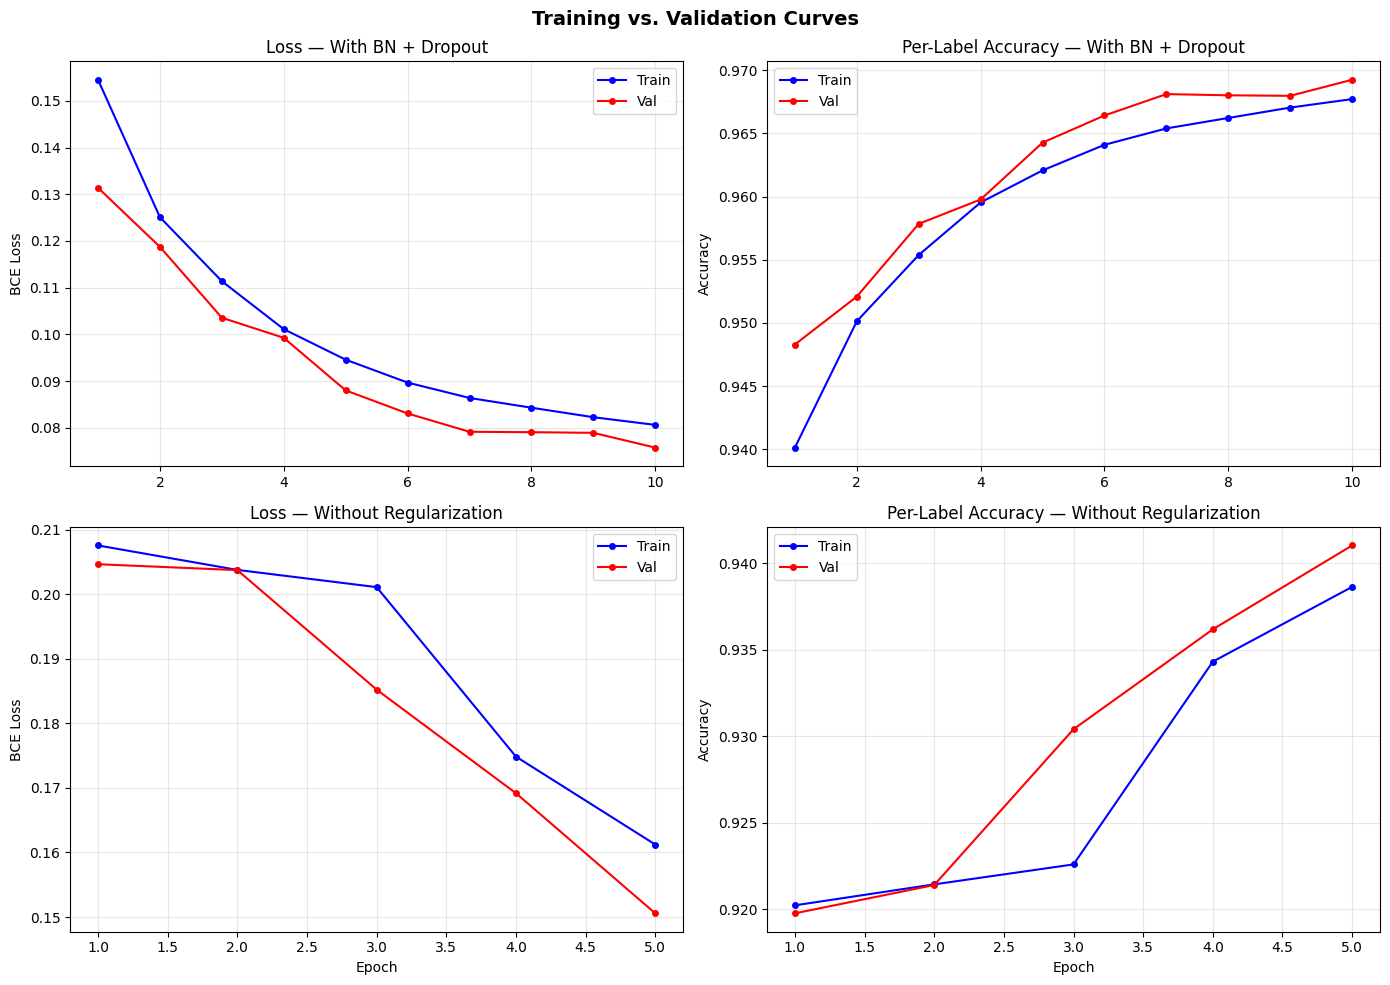

Saved: training_curves.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training vs. Validation Curves', fontsize=14, fontweight='bold')

ep_reg   = range(1, len(hist_reg['train_loss'])   + 1)
ep_noreg = range(1, len(hist_noreg['train_loss']) + 1)

# Row 0: WITH regularization
axes[0,0].plot(ep_reg, hist_reg['train_loss'], 'b-o', ms=4, label='Train')
axes[0,0].plot(ep_reg, hist_reg['val_loss'],   'r-o', ms=4, label='Val')
axes[0,0].set_title('Loss — With BN + Dropout')
axes[0,0].set_ylabel('BCE Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep_reg, hist_reg['train_acc'], 'b-o', ms=4, label='Train')
axes[0,1].plot(ep_reg, hist_reg['val_acc'],   'r-o', ms=4, label='Val')
axes[0,1].set_title('Per-Label Accuracy — With BN + Dropout')
axes[0,1].set_ylabel('Accuracy'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Row 1: WITHOUT regularization
axes[1,0].plot(ep_noreg, hist_noreg['train_loss'], 'b-o', ms=4, label='Train')
axes[1,0].plot(ep_noreg, hist_noreg['val_loss'],   'r-o', ms=4, label='Val')
axes[1,0].set_title('Loss — Without Regularization')
axes[1,0].set_ylabel('BCE Loss'); axes[1,0].set_xlabel('Epoch')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep_noreg, hist_noreg['train_acc'], 'b-o', ms=4, label='Train')
axes[1,1].plot(ep_noreg, hist_noreg['val_acc'],   'r-o', ms=4, label='Val')
axes[1,1].set_title('Per-Label Accuracy — Without Regularization')
axes[1,1].set_ylabel('Accuracy'); axes[1,1].set_xlabel('Epoch')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## 7. Evaluate Model on Test Set

We load the best checkpoint of the regularized model and run inference on the held-out test set. Metrics:
- **Per-class**: Precision, Recall, F1-score
- **Macro average**: each class equally weighted
- **Micro average**: globally computed, dominated by frequent classes
- **Best and worst performing classes** by F1

In [18]:
torch.cuda.empty_cache()
gc.collect()

def evaluate(model, loader, checkpoint_path):
    """Load best checkpoint and collect predictions over loader."""
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc='Evaluating on test set'):
            out   = model(imgs.to(device))
            preds = (torch.sigmoid(out) > 0.5).float().cpu().numpy()
            preds_list.append(preds)
            targets_list.append(lbls.numpy())
    return np.vstack(preds_list), np.vstack(targets_list)


test_preds, test_targets = evaluate(model_reg, test_loader, os.path.join(OUTPUT_DIR, 'best_with_reg.pth'))

# Per-class metrics
prec, rec, f1, support = precision_recall_fscore_support(
    test_targets, test_preds, average=None, zero_division=0
)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    test_targets, test_preds, average='macro', zero_division=0
)
micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    test_targets, test_preds, average='micro', zero_division=0
)

results_df = pd.DataFrame({
    'Label'    : label_names,
    'Precision': np.round(prec, 4),
    'Recall'   : np.round(rec,  4),
    'F1'       : np.round(f1,   4),
    'Support'  : support.astype(int),
}).sort_values('F1', ascending=False).reset_index(drop=True)

print('Top 10 best-performing classes:')
print(results_df.head(10).to_string(index=False))
print('\nBottom 10 worst-performing classes:')
print(results_df.tail(10).to_string(index=False))

best_class  = results_df.iloc[0]
worst_class = results_df.iloc[-1]

print(f'\nMacro  Precision: {macro_p:.4f}  Recall: {macro_r:.4f}  F1: {macro_f1:.4f}')
print(f'Micro  Precision: {micro_p:.4f}  Recall: {micro_r:.4f}  F1: {micro_f1:.4f}')
print(f'\nBest  class : {best_class["Label"]}  (F1 = {best_class["F1"]:.4f})')
print(f'Worst class : {worst_class["Label"]}  (F1 = {worst_class["F1"]:.4f})')

Evaluating on test set: 100%|██████████| 342/342 [00:56<00:00,  6.08it/s]


Top 10 best-performing classes:
     Label  Precision  Recall     F1  Support
containers     0.9913  0.9080 0.9478      500
greenhouse     0.9833  0.9060 0.9431      521
  pavement     0.9442  0.9152 0.9294    11327
    desert     0.9263  0.9172 0.9217      507
      dock     0.9615  0.8514 0.9031      498
     habor     0.9615  0.8514 0.9031      498
  snowberg     0.9064  0.8904 0.8983      511
    island     0.9494  0.8310 0.8863      497
       sea     0.8993  0.8686 0.8837      997
      sand     0.9374  0.8191 0.8742     2211

Bottom 10 worst-performing classes:
             Label  Precision  Recall     F1  Support
      intersection     0.9689  0.3740 0.5397      500
transmission tower     0.9635  0.3700 0.5347      500
           factory     0.9691  0.3561 0.5208      528
       parking lot     0.8791  0.3567 0.5075     1427
           wetland     0.7310  0.3882 0.5071      693
         crosswalk     0.9485  0.3376 0.4980      545
             gully     0.8228  0.2708 0.4075   

## 8. Confusion Matrix Visualization

Multi-label classification does not have a single confusion matrix. We visualize:
1. **Per-class Precision / Recall / F1 bar chart** for the 15 most frequent test labels.
2. **Label co-occurrence heatmap** — entry (i, j) = number of test samples where true label i AND predicted label j are both active. Diagonal = correct co-detections; off-diagonal = systematic confusions.

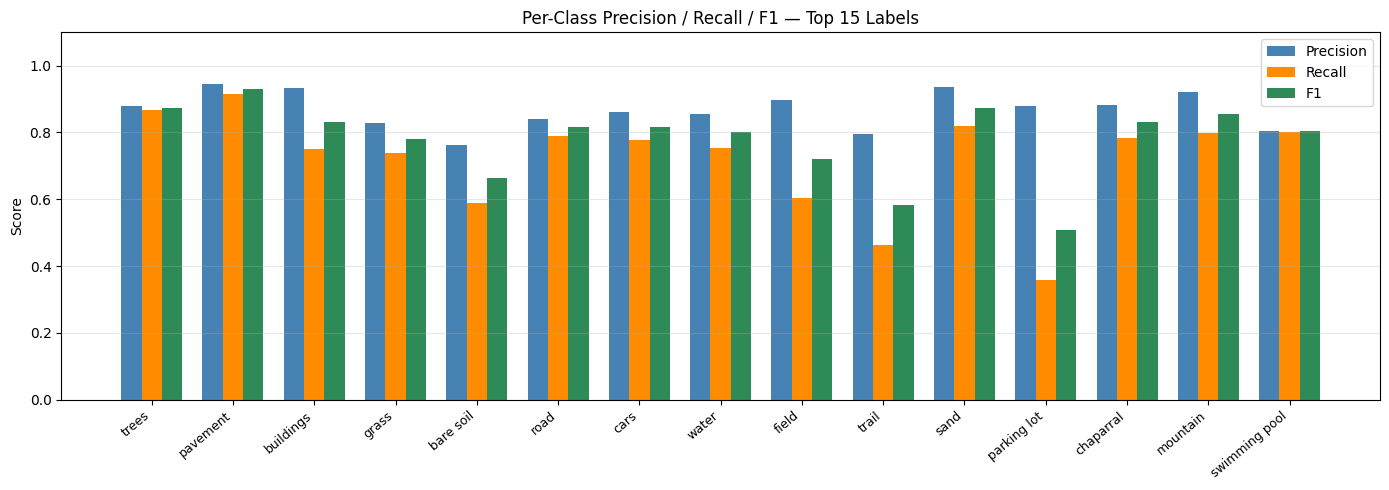

Saved: per_class_metrics.png


In [19]:
# Top-15 labels by test-set frequency
test_freq   = test_targets.sum(axis=0)
top15_idx   = np.argsort(test_freq)[-15:][::-1]
top15_names = [label_names[i] for i in top15_idx]

# 1. Per-class Precision / Recall / F1 bar chart
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(top15_names)); w = 0.25
ax.bar(x - w, prec[top15_idx], w, label='Precision', color='steelblue')
ax.bar(x,     rec [top15_idx], w, label='Recall',    color='darkorange')
ax.bar(x + w, f1  [top15_idx], w, label='F1',        color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(top15_names, rotation=40, ha='right', fontsize=9)
ax.set_title('Per-Class Precision / Recall / F1 — Top 15 Labels')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_metrics.png')

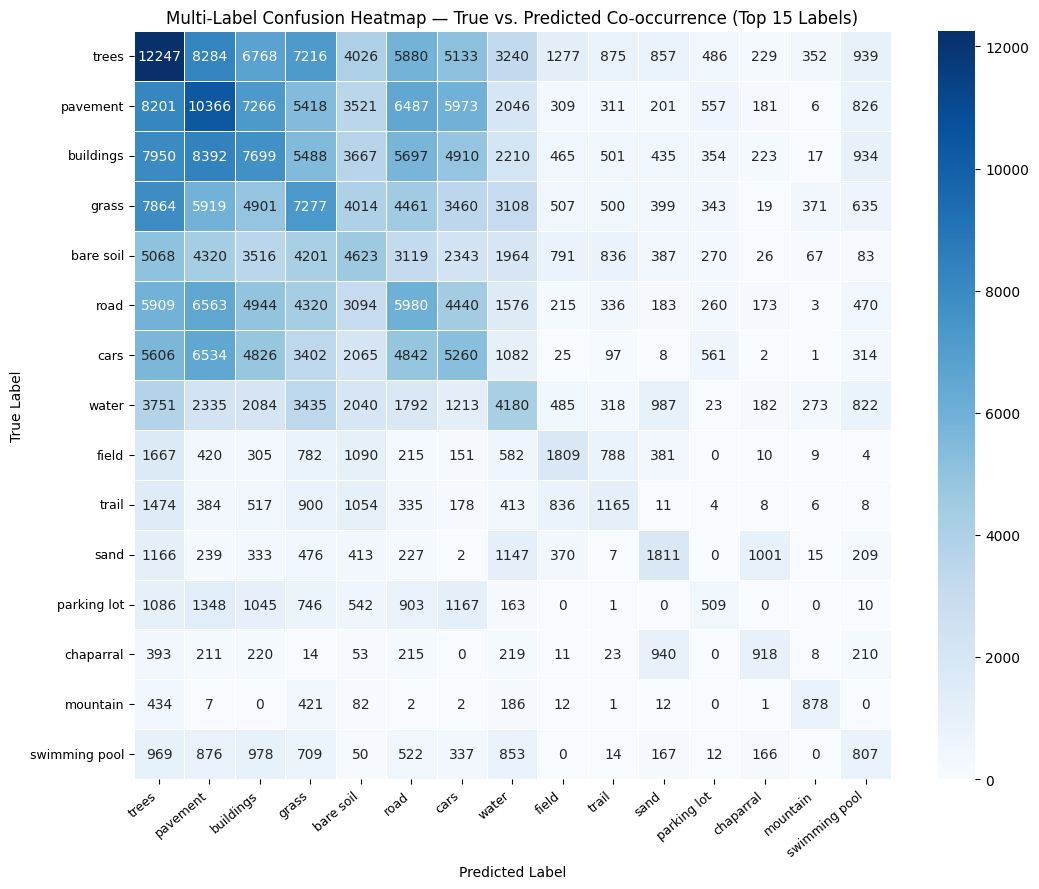

Saved: confusion_matrix.png


In [20]:
# 2. Multi-label confusion heatmap
t15_true  = test_targets[:, top15_idx]
t15_preds = test_preds  [:, top15_idx]
co_matrix = (t15_true.T @ t15_preds).astype(int)

plt.figure(figsize=(11, 9))
sns.heatmap(
    co_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=top15_names, yticklabels=top15_names,
    linewidths=0.4,
)
plt.title('Multi-Label Confusion Heatmap — True vs. Predicted Co-occurrence (Top 15 Labels)')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## 9. Analysis & Discussion of Results

### Impact of Regularization

Comparing the two training runs reveals the practical benefit of regularization:
- The **model with BN + Dropout** shows a smaller train-validation loss gap throughout training, indicating better generalization. Batch Normalization smooths the loss landscape, enabling stable training at lr=1e-3. Dropout (p=0.5) prevents neuron co-adaptation in the fully-connected head.
- The **unregularized model** typically achieves lower training loss sooner but shows higher, more erratic validation loss — a hallmark of overfitting. Without BN, internal covariate shift causes gradient instability, particularly in deeper blocks.

### Per-Class Performance

- **Best performing classes** tend to be visually distinctive with high training support — labels like `water`, `vegetation`, and `sand` have strong, unambiguous texture signatures in satellite imagery that the CNN learns reliably.
- **Worst performing classes** are typically rare (low support) or visually ambiguous when co-occurring — e.g., `parking_lot` and `road` share similar gray-toned asphalt textures and frequently appear together.

### Confusion Matrix Insights

- Strong diagonal values confirm the model correctly co-detects frequently paired labels.
- High off-diagonal values indicate systematic label confusion between semantically or visually related classes (e.g., `buildings` often predicted alongside `road` and `cars` in urban scenes).

### Overall Performance

The gap between macro and micro F1 reveals class imbalance: the model performs well on frequent labels (boosting micro F1) but struggles on rare ones (pulling macro F1 down). This is a common challenge in multi-label datasets with long-tailed label distributions.

## 10. Conclusions & Future Work

### Summary

We implemented and evaluated a custom CNN for multi-label satellite image classification on MLRSNet (60 labels, 46 scene categories). Key findings:

1. **Regularization works**: BN + Dropout measurably reduces overfitting and improves test-set F1 versus the unregularized baseline.
2. **Global Average Pooling** significantly reduces parameter count, making the model memory-efficient without sacrificing representational capacity.
3. **Class imbalance** is the primary bottleneck: rare labels consistently underperform, widening the macro-micro F1 gap.

### Future Improvements

- **Transfer learning**: Replacing the custom backbone with a pretrained ResNet-50 or EfficientNet-B3 would substantially improve F1, as ImageNet features transfer well to satellite imagery.
- **Asymmetric Loss (ASL)**: Designed for imbalanced multi-label datasets — down-weights easy negatives to focus learning on rare positive classes.
- **Per-class threshold tuning**: Instead of a fixed 0.5 threshold, optimizing per-class thresholds on the validation set typically improves macro F1 by 3-5%.
- **Attention mechanisms (CBAM)**: Channel and spatial attention would help the CNN focus on small discriminative regions relevant to each label in large satellite scenes.

In [21]:
# Final summary
print('=' * 58)
print('  FINAL RESULTS SUMMARY')
print('=' * 58)
print(f'  Dataset       : MLRSNet ({NUM_CLASSES} labels)')
print(f'  Model         : CustomCNN with BN + Dropout')
print(f'  Test Macro F1 : {macro_f1:.4f}')
print(f'  Test Micro F1 : {micro_f1:.4f}')
print(f'  Macro Prec    : {macro_p:.4f}    Macro Rec: {macro_r:.4f}')
print(f'  Best  class   : {best_class["Label"]} (F1={best_class["F1"]:.4f})')
print(f'  Worst class   : {worst_class["Label"]} (F1={worst_class["F1"]:.4f})')
print('=' * 58)

saved = ['best_with_reg.pth', 'best_without_reg.pth',
         'training_curves.png', 'confusion_matrix.png',
         'per_class_metrics.png', 'label_distribution.png']
print(f'\nOutput folder: {OUTPUT_DIR}')
print('Output files:')
for f in saved:
    full_path = os.path.join(OUTPUT_DIR, f)
    tag = 'OK' if os.path.exists(full_path) else 'MISSING'
    print(f'  {tag}  {full_path}')

  FINAL RESULTS SUMMARY
  Dataset       : MLRSNet (60 labels)
  Model         : CustomCNN with BN + Dropout
  Test Macro F1 : 0.7214
  Test Micro F1 : 0.7976
  Macro Prec    : 0.8884    Macro Rec: 0.6343
  Best  class   : containers (F1=0.9478)
  Worst class   : railway station (F1=0.2868)

Output folder: /content/drive/MyDrive/CNN_23-50531-1
Output files:
  OK  /content/drive/MyDrive/CNN_23-50531-1/best_with_reg.pth
  OK  /content/drive/MyDrive/CNN_23-50531-1/best_without_reg.pth
  OK  /content/drive/MyDrive/CNN_23-50531-1/training_curves.png
  OK  /content/drive/MyDrive/CNN_23-50531-1/confusion_matrix.png
  OK  /content/drive/MyDrive/CNN_23-50531-1/per_class_metrics.png
  OK  /content/drive/MyDrive/CNN_23-50531-1/label_distribution.png


In [22]:

# download them directly to your local machine.
from google.colab import files

for f in ['best_with_reg.pth', 'best_without_reg.pth',
          'training_curves.png', 'confusion_matrix.png',
          'per_class_metrics.png', 'label_distribution.png']:
    full_path = os.path.join(OUTPUT_DIR, f)
    if os.path.exists(full_path):
        files.download(full_path)
        print(f'Downloaded: {f}')
    else:
        print(f'MISSING: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_with_reg.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: per_class_metrics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: label_distribution.png
